In [1]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os

from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.img_converter import ImgConverter
from converters.line_heuristics.greedy import GreedyLineSearch
from rendering.image import render_symbols_img

from tests.experimental.test_loop import lazy_converter_loop

SYMBOLS = ['@', '%', '#', '+', '=', '^', '-', '|', '\\', '/', ':', '\'', '.', ' ']
FONT_PATH = "../../../../fonts/FiraCode-Regular.ttf"
FONT_SIZE = 10
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
MAX_COLS = 20
MAX_LINES = 10
NUM_IMGS = 10
GENS = 1
GENS_STEP = 1
IMG_SET_PATH = "../../../../imgs/BSDS500-ds"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:NUM_IMGS]]


In [2]:
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery

line_converter = GreedyLineSearch(symbols=SYMBOLS,
                                  font=FONT)

converter = ImgConverter(line_converter, FONT)

line_height = int(FONT_SIZE * 1.333)
col_width = int(line_height / 2)

results = []
for img_path in IMG_PATHS[:6]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    res_arr = converter.img2symbols(img,
                                    max_cols=MAX_COLS,
                                    max_lines=MAX_LINES,
                                    col_width=col_width,
                                    line_height=line_height,
                                    gens_per_step=1000)
    results.append(res_arr)

print_gallery(results, 3)

----------------------------------------------------------------------
| ^^####@@@#++#@@++++- |  ^^|@#=  %.@#%@@:|#^ | %#%%^^  =@@##+@%%^   |
| @@@##@@#++++++++-... | ^' |@@@% ^^@%@ ^ /^  | @@@@@+@@@%^  ...     |
|   @@@%#%@@@@@@@@@=   | +@@@@@^^    ||^^@@|| |     ^'^^#@%^%. #@%@= |
| @@@@/ .  -@@@@|^^%^  | /||^@@@@    |@@@|^^' | @@|\.^^%+@@@%@^^ .^^ |
|   ^^@@@@@@@%|||^^    |  %^|#@@%    ||@@#@#  | @@@@%  @ %  . ^ ^ || |
| -@@@@@@@%@@%%^'      | #%^@@@@@.  #^  +|/^| | ^^@^^       .@@@@@@# |
| ^^^^^^^^^^^^^^^^^^^^ | ^^^^^\^^^ ^^^^^ ^^^^ | ^^^ ^^^^^^^^^^^^^^^^ |
----------------------------------------------------------------------
----------------------------------------------------------------
|    ^^ |@@|@@@. | @+@@#%@=+--.@%#.  .| | @@     %##%@%|@||    |
|    . .|  | .   | @%/%#=#+@@@.'^^@^%@@ | @@%#%%.^  | |^    ^' |
| #############= | -@@@@@#=@@%^ ^^   ^# | @@@| '  ^^^@%|/  ..| |
| ++#########+== | @@@@@@^%^ '|^        | @@@@#%%     |..@%|   |
| @@@@|^^^ @@@@@ | @##@%^@@|#%   '  

Min: 0.0202 | Max: 0.3457 | Mean: 0.2024 | Std: 0.0923


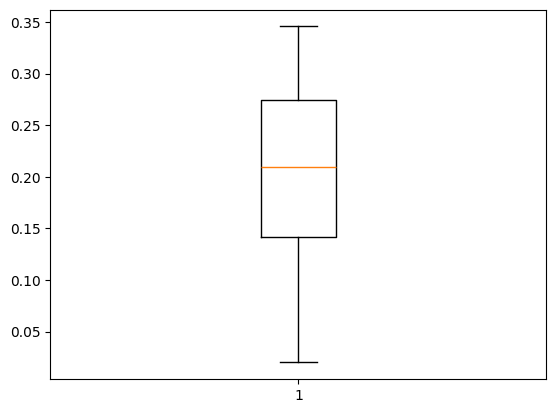

In [3]:
similarity_scores = lazy_converter_loop(IMG_PATHS,
                                        converter,
                                        FONT,
                                        max_cols=MAX_COLS,
                                        max_lines=MAX_LINES,
                                        col_width=col_width,
                                        line_height=line_height,
                                        gens=GENS,
                                        gens_per_step=GENS_STEP)

plt.boxplot(similarity_scores)
plt.show()
        

Min: 0.0054 | Max: 0.2442 | Mean: 0.1328 | Std: 0.0643


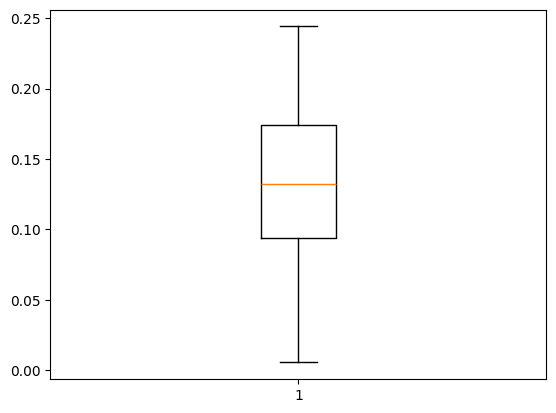

In [4]:
IMG_BIN_SET_PATH = "../../../../imgs/BSDS500-ds-bin"
IMG_BIN_PATHS = [os.path.join(IMG_BIN_SET_PATH, img_name)
                 for img_name in os.listdir(IMG_BIN_SET_PATH)[:NUM_IMGS]]

similarity_scores = lazy_converter_loop(IMG_BIN_PATHS,
                                        converter,
                                        FONT,
                                        max_cols=MAX_COLS,
                                        max_lines=MAX_LINES,
                                        col_width=col_width,
                                        line_height=line_height,
                                        gens=GENS,
                                        gens_per_step=GENS_STEP)

plt.boxplot(similarity_scores)
plt.show()
        

Min: 0.0230 | Max: 0.5935 | Mean: 0.2043 | Std: 0.1583


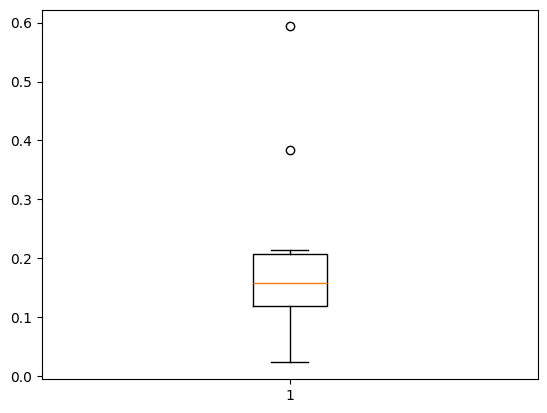

In [5]:
IMG_EDGE_SET_PATH = "../../../../imgs/BSDS500-ds-edge-bin"
IMG_EDGE_PATHS = [os.path.join(IMG_EDGE_SET_PATH, img_name)
                  for img_name in os.listdir(IMG_EDGE_SET_PATH)[:NUM_IMGS]]

similarity_scores = lazy_converter_loop(IMG_EDGE_PATHS,
                                        converter,
                                        FONT,
                                        max_cols=MAX_COLS,
                                        max_lines=MAX_LINES,
                                        col_width=col_width,
                                        line_height=line_height,
                                        gens=GENS,
                                        gens_per_step=GENS_STEP)

plt.boxplot(similarity_scores)
plt.show()
        